In [1]:
from ESRNN.utils_evaluation import evaluate_prediction_owa
from ESRNN import ESRNN
from ESRNN.utils_evaluation import Naive2, Naive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pickle


In [4]:
df = pd.read_csv(
    "/home/erti/PROJECT_repos/ForeST_HPO/hpo-innosuisse/data/2024-05-27 DE Auftragseingang Maschinenbau 28.00.csv"
)
df.columns

Index(['Datum', 'Insgesamt', 'Inland', 'Ausland', 'Ausland (Eurozone)',
       'Ausland (Nicht-Eurozone)'],
      dtype='object')

In [5]:
y_df = pd.DataFrame()
y_df["ds"] = pd.to_datetime(df["Datum"])
y_df["y"] = df["Insgesamt"]
y_df["unique_id"] = "Insgesamt"


In [6]:
assert y_df.isna().sum().sum() == 0, "There are NaN values in the data"

In [7]:
x_df = y_df.drop("y", 1)
x_df["x"] = "Macro"  # TODO

In [8]:
SPLIT_IDX = y_df[y_df.ds == pd.to_datetime("2017-01-31")].index[0]
print(SPLIT_IDX, SPLIT_IDX / len(y_df))

y_train_df = y_df.iloc[:SPLIT_IDX]
y_test_df = y_df.iloc[SPLIT_IDX:]

X_train_df = x_df.iloc[:SPLIT_IDX]
X_test_df = x_df.iloc[SPLIT_IDX:]

312 0.7819548872180451


In [9]:
# naive = Naive() # TODO use Naive2 or SesonalNaive
# naive.fit(y_test_df)

y_test_df["y_hat_naive2"] = y_test_df["y"].shift(1).fillna(method="bfill")

/tmp/nix-shell-81580-0/ipykernel_97013/1444109779.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test_df["y_hat_naive2"] = y_test_df["y"].shift(1).fillna(method="bfill")


In [ ]:
# ESRNN Default Inits
#     max_epochs=15,
#     batch_size=1,
#     batch_size_test=64,
#     freq_of_test=-1,
#     learning_rate=1e-3,
#     lr_scheduler_step_size=9,
#     lr_decay=0.9,
#     per_series_lr_multip=1.0,
#     gradient_eps=1e-8,
#     gradient_clipping_threshold=20,
#     rnn_weight_decay=0,
#     noise_std=0.001,
#     level_variability_penalty=80,
#     testing_percentile=50,
#     training_percentile=50,
#     ensemble=False,
#     cell_type="LSTM",
#     state_hsize=40,
#     dilations=[[1, 2], [4, 8]],
#     add_nl_layer=False,
#     seasonality=[4],
#     input_size=4,
#     output_size=8,
#     frequency=None,
#     max_periods=20,
#     random_seed=1,
#     device="cpu",
#     root_dir="./",


In [ ]:
# Instantiate model

INPUT_SIZE = 12
OUTPUT_SIZE = 6

hparams = dict(
    max_epochs=15,
    freq_of_test=-1,
    # learning_rate=5e-4,
    # lr_scheduler_step_size=10,
    # lr_decay=0.1,
    per_series_lr_multip=0.8,
    # gradient_eps=
    gradient_clipping_threshold=50,
    rnn_weight_decay=0.0, # L2 Norm
    # noise_std=
    level_variability_penalty=50,
    testing_percentile=50,
    training_percentile=50, # Pinball Loss
    batch_size=1,  # assert self.batch_size <= self.n_series
    seasonality=[12],
    input_size=INPUT_SIZE,
    output_size=OUTPUT_SIZE,
    # random_seed=
    # exogenous_size=0, # does not exist...
    # min_inp_seq_length=
    max_periods=120,
    cell_type="LSTM",
    state_hsize=64,
    dilations=[[1], [3], [6], [12]],
    add_nl_layer=False,
    random_seed=1,
    device="cuda",  # FIXED ERTI
    ensemble=False,
)

model = ESRNN(**hparams)

In [84]:
# with open("forest_model.pkl", "rb") as f:
#     model = pickle.load(f)

In [146]:
# Fit model
# If y_test_df is provided the model will evaluate predictions on this set every freq_test epochs


model.fit(
    X_train_df,
    y_train_df,
    X_test_df,
    y_test_df,
)

with open("forest_model.pkl", "wb") as f:
    pickle.dump(model, f)


RuntimeError: CUDA error: unspecified launch failure
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [145]:
# Predict on test set
# HINT is only a "local" model. Can only predict contiguous to training and needs to be retrained
i = 0
y_hat_df = model.predict(X_test_df[i:i+OUTPUT_SIZE])

# Evaluate predictions
final_owa, final_mase, final_smape = evaluate_prediction_owa(
    y_hat_df,
    # y_train_df,
    y_df[:SPLIT_IDX+i],
    X_test_df[i:i+OUTPUT_SIZE],
    y_test_df[i:i+OUTPUT_SIZE],
    naive2_seasonality=1,
)

AssertionError: Model not fitted yet

M4 Parameters:

    OWA: 0.966 
    SMAPE: 7.683 
    MASE: 1.528 

Monthly Parameters (Paper Table 1):

    OWA: 0.521 
    SMAPE: 4.278 
    MASE: 0.8 

Own Parameters (1):

    OWA: 0.399 
    SMAPE: 3.251 
    MASE: 0.616

Own Parameters (2 - LR defaults):

    OWA: 0.294 
    SMAPE: 2.419 
    MASE: 0.45


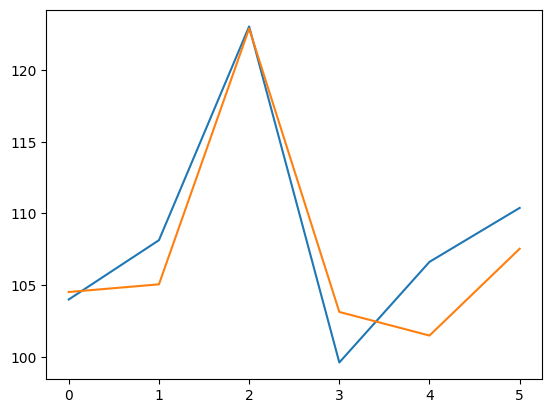

In [87]:
plt.plot(y_test_df[:6].y.values, label="y")
plt.plot(y_hat_df[:6].y_hat.values, label="y_hat")

In [88]:
y_hat_df["y_test"] = y_test_df["y"]

In [89]:
y_hat_df.to_csv("y_hat_df.csv")

## Historical Forecasts

In [104]:
y_test_df.iloc[0]

ds              2017-01-31 00:00:00
y                            104.01
unique_id                 Insgesamt
y_hat_naive2                 104.01
Name: 312, dtype: object

In [ ]:
STRIDE = 1
hfcs_dfs = []
metrics = []
for i in range(0, len(y_test_df)-OUTPUT_SIZE,STRIDE):
    # print(y_test_df.iloc[i].ds, y_test_df.iloc[i+OUTPUT_SIZE].ds)
    split_idx_ = y_test_df.iloc[i].name
    X_train_, X_predict_ = x_df[:split_idx_], x_df[split_idx_:split_idx_+OUTPUT_SIZE]
    y_train_ = y_df[:split_idx_]
    print(split_idx_, X_train_.index[-1], X_train_.iloc[-1].ds)
    model_ = ESRNN(**hparams)
    # model_ = ESRNN(**(hparams|{"max_epochs": 1}))
    model_.fit(
        X_train_,
        y_train_,
    )
    y_hat_df_ = model_.predict(
        X_predict_,
    )
    hfcs_dfs.append(y_hat_df_)
    # Metrics
    # metrics_ = evaluate_prediction_owa(
    #     y_hat_df=y_hat_df_,
    #     y_train_df=y_train_,
    #     X_test_df=X_predict_,
    #     y_test_df=y_df[split_idx_:split_idx_+OUTPUT_SIZE],
    #     naive2_seasonality=1,
    #     # y_hat_df,
    #     # # y_train_df,
    #     # y_df[:SPLIT_IDX+i],
    #     # X_test_df[i:i+OUTPUT_SIZE],
    #     # y_test_df[i:i+OUTPUT_SIZE],
    #     # naive2_seasonality=1,
    # )
    # metrics.append(metrics_)

312 311 2016-12-31 00:00:00
Infered frequency: M
=============== Training ESRNN  ===============

========= Epoch 0 finished =========
Training time: 0.33891
Training loss (50 prc): 0.25173
========= Epoch 1 finished =========
Training time: 0.32869
Training loss (50 prc): 0.23709
========= Epoch 2 finished =========
Training time: 0.32411
Training loss (50 prc): 0.22896
========= Epoch 3 finished =========
Training time: 0.3217
Training loss (50 prc): 0.22638
========= Epoch 4 finished =========
Training time: 0.32041
Training loss (50 prc): 0.22520
========= Epoch 5 finished =========
Training time: 0.34734
Training loss (50 prc): 0.22485
========= Epoch 6 finished =========
Training time: 0.33221
Training loss (50 prc): 0.22516
========= Epoch 7 finished =========
Training time: 0.32176
Training loss (50 prc): 0.22501
========= Epoch 8 finished =========
Training time: 0.324
Training loss (50 prc): 0.22356
========= Epoch 9 finished =========
Training time: 0.33156
Training loss (50

In [ ]:
hfcs_dfs[-1]

,ds,unique_id,x,y_hat
0,2023-09-30,Insgesamt,Macro,125.942337
1,2023-10-31,Insgesamt,Macro,115.591629
2,2023-11-30,Insgesamt,Macro,122.198502
3,2023-12-31,Insgesamt,Macro,122.112396
4,2024-01-31,Insgesamt,Macro,120.428780
5,2024-02-29,Insgesamt,Macro,108.116768


In [ ]:
with open("hfcs_dfs.pkl", "wb") as f:
    pickle.dump(hfcs_dfs, f)

In [144]:
with open("hparams.txt", "w") as f:
    f.write(str(hparams))

## as csv

In [3]:
with open("hfcs_dfs.pkl", "rb") as f:
    hfcs_dfs = pickle.load(f)

In [12]:
hfcs_s = []
for df in hfcs_dfs:
    s = df.T.loc["y_hat"]
    s.name = df.ds[0]
    hfcs_s.append(s)

In [15]:
hfcs_df = pd.concat(hfcs_s, axis=1).T
hfcs_df

,0,1,2,3,4,5
2017-01-31,104.530006,105.06459,122.888878,103.140167,101.496559,107.543358
2017-02-28,105.905998,123.453339,109.190346,99.978996,114.90509,106.077469
2017-03-31,127.015526,111.644478,107.686325,114.783363,115.567612,96.813484
2017-04-30,111.035172,106.84549,119.657097,111.479912,101.787125,108.956932
2017-05-31,101.254395,113.274811,111.187973,93.981369,109.017105,99.817963
...,...,...,...,...,...,...
2023-05-31,117.197418,127.741318,125.243164,113.228081,132.277588,114.559303
2023-06-30,129.087906,125.540031,119.474358,130.862503,122.670578,121.225044
2023-07-31,128.13353,121.088539,139.976669,122.402046,130.906357,129.556381
2023-08-31,111.594231,128.089462,118.362068,118.649368,126.186394,115.485847


In [16]:
hfcs_df.to_csv("hfcs.csv")